# **EDA for LLM predictions**

#### **Importing Libraries**

In [2]:
import json
import urllib
import pandas as pd
from sqlalchemy import create_engine
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# To display full content of dataframe cells
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)


#### **SQL Engine**

In [3]:
# Load credentials
with open("../passcode.json", "r") as f:
    cfg = json.load(f)["DB_NAMES"]["AI"]

# Build engine
pwd_encoded = urllib.parse.quote(cfg['PWD'])
engine = create_engine(f"mssql+pymssql://{cfg['UID']}:{pwd_encoded}@{cfg['Server']}/{cfg['Database']}")

# Query
query = "SELECT * FROM dbo.Claims_Predictions_History"

# Chunked read with progress
chunksize = 50_000
conn = engine.raw_connection()
chunks = pd.read_sql(query, conn, chunksize=chunksize)

dfs = []
for i, chunk in enumerate(tqdm(chunks, desc="Reading from SQL Server")):
    dfs.append(chunk)

df = pd.concat(dfs, ignore_index=True)
conn.close()

/tmp/ipykernel_524027/2199804564.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  chunks = pd.read_sql(query, conn, chunksize=chunksize)
Reading from SQL Server: 32it [00:29,  1.09it/s]


#### **EDA**

In [4]:
# Display the dataframe
df

,VisitID,VisitServiceID,Diagnose,Chief_Complaint,ProblemNote,Symptoms,Medical_Prediction,Reason/Recommendation,InsertionDate,Service_Name
0,511131,1908773,None,None,None,None,Rejected,Diagnosis was not found,2025-05-21 11:02:11.547,None
1,502890,1819141,Acute nasopharyngitis [common cold],"8 months, cough 3 days , nasal block, no fever",None,"8 months, cough 3 days , nasal block, no fever",Rejected,FENISTIL 20 ML DROPS is not indicated in this case of acute nasopharyngitis (J00). It is an antihistamine typically used for allergic reactions or itching. Do you suspect an allergic component? Please note it in your diagnosis if so.,NaT,None
2,502890,1819142,Acute nasopharyngitis [common cold],"8 months, cough 3 days , nasal block, no fever",None,"8 months, cough 3 days , nasal block, no fever",Rejected,"APISAL NASAL SPRAY 15 ML is not medically justified for acute nasopharyngitis (J00). It is a nasal decongestant, but its use is not typically recommended for viral upper respiratory infections like this. Consider saline nasal spray as a safer alternative for symptom relief.",NaT,None
3,497221,1819145,"Guillain-Barre syndrome , Guillain-Barre syndrome , Guillain-Barre syndrome","BILATERAL LOWER LIMBS AND UPPER LIMBS WEAKNESS WITH ASCENDING PARALYSIS,BILATERAL LOWER LIMBS AND UPPER LIMbS WEAKNESS WITH ASCENDING PARALYSIS",None,None,Rejected,Inpatient rehabilitation is not indicated for Guillain-Barré syndrome (G61.0) unless there are severe complications or significant functional impairments. Please document the specific functional impairments or complications that necessitate inpatient rehabilitation in your notes.,NaT,None
4,488776,1819131,"Acute myocardial infarction , Acute myocardial infarction, unspecified , Acute myocardial infarction",Chest pain,WITH ACUTE PUL . EDEMA,None,Rejected,Dextrose 5%-50ml bag is not indicated in this case of acute myocardial infarction (I21). Do you suspect hypoglycemia? Please note it in your diagnosis.,NaT,None
...,...,...,...,...,...,...,...,...,...,...
1597128,837290,5704558,Hyperplasia of prostate,F-UP WITH PARTIAL IMPROVEMENT,None,NAD,Rejected,"Omnic OCAS 0.4 mg is a tamsulosin medication for benign prostatic hyperplasia (BPH). The patient's diagnosis is N40 (Benign prostatic hyperplasia without lower urinary tract symptoms). The symptoms are noted as NAD (No Apparent Distress). Since there are no reported urinary symptoms, initiating this medication is not currently medically justified. If the patient has bothersome lower urinary tract symptoms (LUTS) related to BPH, please document them in the symptoms or assessment to justify treatment.",2026-01-19 16:39:34.067,OMNIC OCAS 0.4 MG 30 TAB
1597129,837459,5703964,Calculus of kidney,right renal stone post flexible URS and DJS insertion 10 days ago Less,None,None,Approved,None,2026-01-19 16:39:34.067,Examination
1597130,832630,5704959,Hyperplasia of prostate,difficult micturation,None,None,Rejected,This medication is a laxative and is not indicated for the diagnosis of N40 (Benign prostatic hyperplasia). Do you suspect constipation as a related symptom? Please note it in your diagnosis or clinical notes to justify this prescription.,2026-01-19 16:39:34.070,AGIOLAX GRANULES 250 GM
1597131,837574,5704940,None,None,None,None,Rejected,Diagnosis was not found,2026-01-19 16:39:34.070,Examination


In [5]:
# Show dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597133 entries, 0 to 1597132
Data columns (total 10 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VisitID                1597133 non-null  int64         
 1   VisitServiceID         1597133 non-null  int64         
 2   Diagnose               1494548 non-null  object        
 3   Chief_Complaint        1476409 non-null  object        
 4   ProblemNote            108127 non-null   object        
 5   Symptoms               230600 non-null   object        
 6   Medical_Prediction     1597133 non-null  object        
 7   Reason/Recommendation  848428 non-null   object        
 8   InsertionDate          1569247 non-null  datetime64[ns]
 9   Service_Name           497273 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 121.9+ MB


In [6]:
# Sample for EDA
eda_df = df.sample(100_000, random_state=42)

In [7]:
# Value counts and precentage for Medical_Prediction
print(eda_df["Medical_Prediction"].value_counts()) 
print("------------------------------------------")
print(eda_df["Medical_Prediction"].value_counts(normalize=True) * 100)

Medical_Prediction
Rejected    53054
Approved    46946
Name: count, dtype: int64
------------------------------------------
Medical_Prediction
Rejected    53.054
Approved    46.946
Name: proportion, dtype: float64


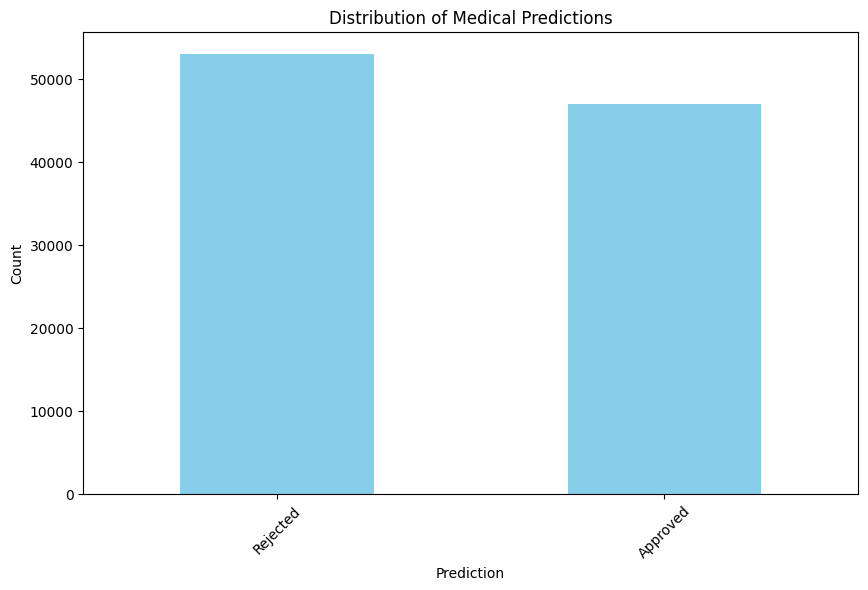

In [8]:
# Bar plot for Medical_Prediction distribution
plt.figure(figsize=(10, 6))
eda_df["Medical_Prediction"].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Medical Predictions')
plt.xlabel('Prediction')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [9]:
# How many times the same service was repeated for the same visit.
visit_service_counts = (
    eda_df
    .groupby(["VisitID", "Service_Name"])
    .size()
    .reset_index(name="count")
)

visit_service_counts.sort_values("count", ascending=False).head(30)

,VisitID,Service_Name,count
15586,774598,ALBUREX 20 % 50 ML,46
15601,774598,SYRINGES 20CC NEEDLE (21GX1.5),38
17354,791589,ECHOCARDIOGRAM,29
17353,791589,CREATININE IN SERUM,28
17355,791589,ICU/ PICU admission 2nd + 3rd day (collectively),27
17351,791589,BLOOD GLUCOSE BY REFLOCHECK,26
15589,774598,BETADINE DRY POWDER SPRAY,24
17358,791589,"VIRUS SCREENING (HIV, HBSAG, HCV)",24
17357,791589,TSH (THYROID STIMULATING HORMONE),24
16589,789033,ZOLAN 5 MG 30 TAB,22


In [10]:
# Find conflicts in predictions for the same VisitID , Service_Name and Diagnose
conflict_vs = (
    eda_df
    .groupby(["VisitID", "Service_Name"])
    .agg(
        n_unique_predictions=("Medical_Prediction", "nunique"),
        predictions=("Medical_Prediction", lambda x: list(x.dropna().unique())),
        n_unique_diagnoses=("Diagnose", "nunique"),
        diagnoses=("Diagnose", lambda x: list(x.dropna().unique()))
    )
    .reset_index()
)

conflicts = conflict_vs[
    (conflict_vs["n_unique_predictions"] > 1) &
    (conflict_vs["n_unique_diagnoses"] > 1)
]


print(f"Number of conflicts: {conflicts.shape[0]}")
print("--------------------------------------------------------")
conflict_rate = len(conflicts) / eda_df[["VisitID","Service_Name"]].drop_duplicates().shape[0]
print("Percentage of conflicts: {:.4f}%".format(conflict_rate * 100))
conflicts.head()

Number of conflicts: 138
--------------------------------------------------------
Percentage of conflicts: 0.2417%


,VisitID,Service_Name,n_unique_predictions,predictions,n_unique_diagnoses,diagnoses
16,653325,LECTRA 100 MG INF,2,"[Rejected, Approved]",2,"[Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration , Septic shock, Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration]"
18,653325,SCREENING FOR FRESH FROZEN PLASMA POSITIVE,2,"[Rejected, Approved]",2,"[Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration, Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration , Septic shock]"
247,711578,SYRINGES 5CC NEEDLE (22GX1.5),2,"[Approved, Rejected]",2,"[Pain, not elsewhere classified , Acute kidney failure , Carcinoma in situ of liver, gallbladder and bile ducts , Encephalopathy, unspecified, Pain, not elsewhere classified , Carcinoma in situ of liver, gallbladder and bile ducts , Acute kidney failure , Encephalopathy, unspecified]"
338,711616,BABY JOY SIZE 1 NEONATE OLIVE,2,"[Approved, Rejected]",2,"[Singleton, born in hospital , Liveborn infants according to place of birth, Liveborn infants according to place of birth , Singleton, born in hospital]"
939,721775,BLOOD GLUCOSE BY REFLOCHECK,2,"[Rejected, Approved]",2,"[Septic shock , Orthostatic hypotension , Acute maxillary sinusitis, Septic shock]"


In [11]:
# Expand to see diagnoses per prediction per visit and service
expanded = (
    eda_df
    .groupby(["VisitID", "Service_Name", "Medical_Prediction"])
    .agg(
        diagnoses=("Diagnose", lambda x: list(x.dropna().unique()))
    )
    .reset_index()
)

multi_pred_visits = (
    expanded
    .groupby(["VisitID", "Service_Name"])["Medical_Prediction"]
    .nunique()
    .reset_index(name="n_predictions")
)

multi_pred_visits = multi_pred_visits[multi_pred_visits["n_predictions"] > 1]

final_view = expanded.merge(
    multi_pred_visits[["VisitID", "Service_Name"]],
    on=["VisitID", "Service_Name"],
    how="inner"
).sort_values(["VisitID", "Service_Name", "Medical_Prediction"])

final_view.head(20)

,VisitID,Service_Name,Medical_Prediction,diagnoses
0,653325,LECTRA 100 MG INF,Approved,"[Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration]"
1,653325,LECTRA 100 MG INF,Rejected,"[Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration , Septic shock]"
2,653325,SCREENING FOR FRESH FROZEN PLASMA POSITIVE,Approved,"[Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration , Septic shock]"
3,653325,SCREENING FOR FRESH FROZEN PLASMA POSITIVE,Rejected,"[Stroke, not specified as haemorrhage or infarction , Acute kidney failure , Loss of consciousness of unspecified duration]"
4,662423,LAVIE 500 MG 30 TAB,Approved,"[Stroke, not specified as haemorrhage or infarction]"
5,662423,LAVIE 500 MG 30 TAB,Rejected,"[Stroke, not specified as haemorrhage or infarction]"
6,662423,NEPRO HP VANILLA 30X220 ML,Approved,"[Stroke, not specified as haemorrhage or infarction]"
7,662423,NEPRO HP VANILLA 30X220 ML,Rejected,"[Stroke, not specified as haemorrhage or infarction]"
8,683970,SODIUM IN SERUM,Approved,"[Other bacterial pneumonia , Pneumonia, organism unspecified , Volume depletion]"
9,683970,SODIUM IN SERUM,Rejected,"[Other bacterial pneumonia , Pneumonia, organism unspecified , Volume depletion]"


In [12]:
# Services with most conflicts
conflict_services = (
    eda_df.merge(
        conflicts[["VisitID", "Service_Name"]],
        on=["VisitID", "Service_Name"]
    )
    .groupby("Service_Name")
    .size()
    .sort_values(ascending=False)
)

conflict_services.head(30)

Service_Name
IV ADMIN OF PHARMAC AGT OTH & UNSP AGENT                                      16
COMPLETE BLOOD COUNT.                                                         15
BLOOD GLUCOSE BY  REFLOCHECK                                                  15
CREATININE IN SERUM                                                           14
GAUZE SPONGE 4X4                                                              11
UNDER PAD BIG 60X90                                                           10
INHIXA 80 MG                                                                   9
SYRINGES  3CC NEEDLE (23GX1.25)                                                8
METRONIDAZOLE 500MG/100ML INTRAVENOUS INFUSION(PSI)                            8
PIPERACILLIN-TAZOBACTAM SANDOZ 4.5 GM VIAL                                     8
ONDANSETRON 4 MG 2 ML 5 AMP                                                    7
C.R.P. (QUANTITATIVE)                                                          7
SPECIMEN BAG 6X

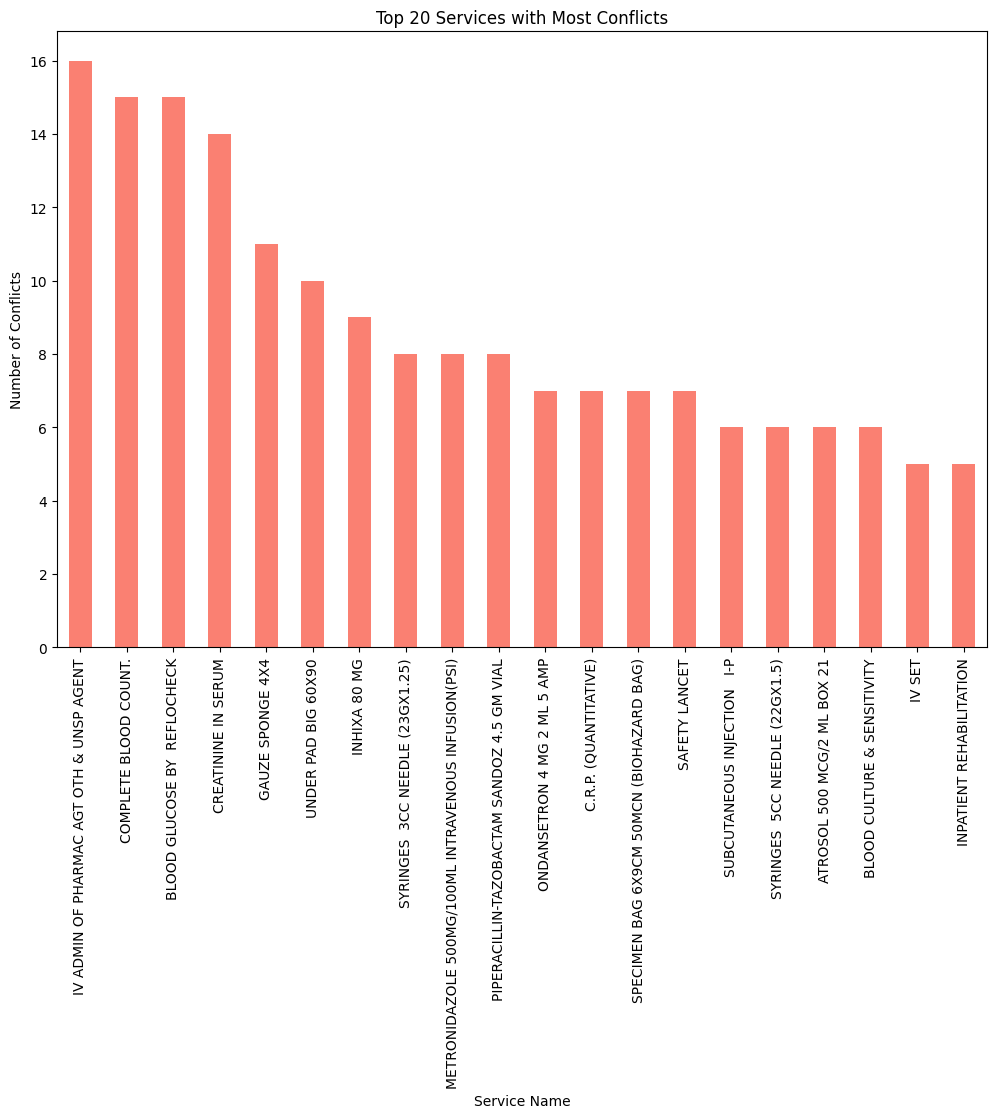

In [13]:
# Bar plot for services with most conflicts
plt.figure(figsize=(12, 8))
conflict_services.head(20).plot(kind='bar', color='salmon')
plt.title('Top 20 Services with Most Conflicts')
plt.xlabel('Service Name')
plt.ylabel('Number of Conflicts')
plt.xticks(rotation=90)
plt.show()

In [14]:
# Calculate risk per service based on number of conflicting visits
service_conflict_counts = (
    final_view
    .groupby("Service_Name")["VisitID"]
    .nunique()
    .reset_index(name="n_conflicting_visits")
    .sort_values("n_conflicting_visits", ascending=False)
)

service_total_counts = (
    eda_df
    .groupby("Service_Name")["VisitID"]
    .nunique()
    .reset_index(name="total_visits")
)

service_risk = service_total_counts.merge(
    service_conflict_counts,
    on="Service_Name",
    how="left"
)

service_risk["n_conflicting_visits"] = (
    service_risk["n_conflicting_visits"].fillna(0)
)


service_risk.sort_values("n_conflicting_visits", ascending=False).head(20)

,Service_Name,total_visits,n_conflicting_visits
706,Examination,3040,88.0
255,BLOOD GLUCOSE BY REFLOCHECK,298,32.0
1010,IV ADMIN OF PHARMAC AGT OTH & UNSP AGENT,170,16.0
290,C.R.P. (QUANTITATIVE),373,13.0
1302,NORMAL SALINE 50ML- SODIUM CHLORIDE 0.9% INFUSION 50ML BAG(PSI),151,13.0
1306,NOVANET STATSTRIP GLUCOSE STRIPS (1 STRIP),286,12.0
821,GAUZE SPONGE 4X4,199,12.0
1019,IV SET,274,10.0
63,AIR . MATRESS(DAY),99,10.0
390,COMPLETE BLOOD COUNT.,813,10.0


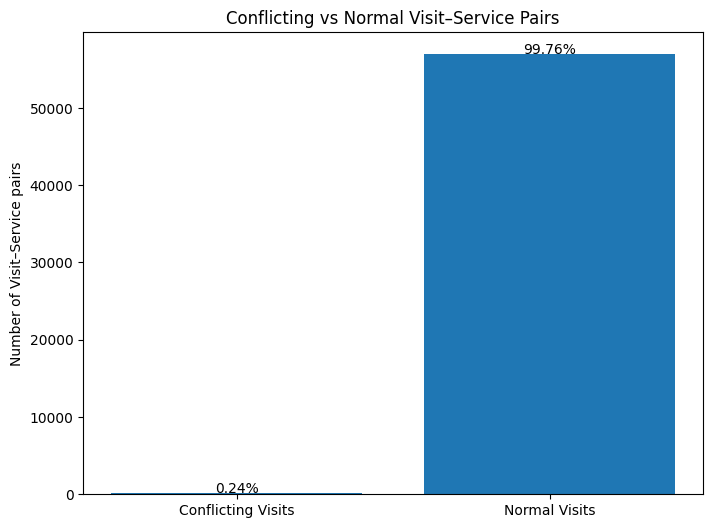

In [15]:
# Bar plot for total conflicting visits vs normal visits
total_vs = eda_df[["VisitID", "Service_Name"]].drop_duplicates().shape[0]
total_conflicting = conflicts.shape[0]
total_normal = total_vs - total_conflicting

plt.figure(figsize=(8, 6))
plt.bar(
    ['Conflicting Visits', 'Normal Visits'],
    [total_conflicting, total_normal]
)
plt.title('Conflicting vs Normal Visit–Service Pairs')
plt.ylabel('Number of Visit–Service pairs')

# add percentages on bars
plt.text(0, total_conflicting, f"{(total_conflicting/total_vs)*100:.2f}%", ha='center')
plt.text(1, total_normal, f"{(total_normal/total_vs)*100:.2f}%", ha='center')

plt.show()

In [16]:
# Diagnosis missing but Medical_Prediction present (rejected)
missing_diagnosis = eda_df[
    eda_df["Diagnose"].notna() &
    (
        eda_df["Diagnose"].str.strip().ne("") &
        eda_df["Medical_Prediction"].isna()
    )
]

Diagnosis_missing_count = missing_diagnosis[["VisitID","Service_Name"]].drop_duplicates().shape[0]
total_vs = eda_df[["VisitID","Service_Name"]].drop_duplicates().shape[0]

Diagnosis_missing_rate = (Diagnosis_missing_count / total_vs) * 100

print("Diagnosis missing")
print("Count:", Diagnosis_missing_count)
print(f"Percentage: {Diagnosis_missing_rate:.4f}%")

Diagnosis missing
Count: 0
Percentage: 0.0000%


In [17]:
# No Medical_Prediction provided
no_prediction = eda_df[
    eda_df["Medical_Prediction"].isna() |
    eda_df["Medical_Prediction"].str.strip().eq("")
]

no_prediction_count = no_prediction[["VisitID","Service_Name"]].drop_duplicates().shape[0]
no_prediction_rate = (no_prediction_count / total_vs) * 100

print("No prediction")
print("Count:", no_prediction_count)
print(f"Percentage: {no_prediction_rate:.4f}%")

No prediction
Count: 0
Percentage: 0.0000%


In [18]:
# Find duplicated VisitID and Service_Name entries to check insertion date
dup_vs = (
    eda_df
    .groupby(["VisitID", "Service_Name"])
    .size()
    .reset_index(name="count")
)

dup_vs = dup_vs[dup_vs["count"] > 1]

dup_details = eda_df.merge(
    dup_vs[["VisitID", "Service_Name"]],
    on=["VisitID", "Service_Name"],
    how="inner"
).sort_values(["VisitID", "Service_Name", "InsertionDate"])

dup_summary = (
    dup_details
    .groupby(["VisitID", "Service_Name"])
    .agg(
        first_insertion=("InsertionDate", "min"),
        last_insertion=("InsertionDate", "max"),
        n_times=("InsertionDate", "count"),
        insertion_dates=("InsertionDate", lambda x: list(x))
    )
    .reset_index()
)

dup_summary["diff_minutes"] = (
    dup_summary["last_insertion"] - dup_summary["first_insertion"]
).dt.total_seconds() / 60


dup_summary.head(20)

,VisitID,Service_Name,first_insertion,last_insertion,n_times,insertion_dates,diff_minutes
0,528388,ARTELAC NIGHTTIME 10GM GEL,2026-01-18 07:29:14.833,2026-01-18 07:31:56.773,2,"[2026-01-18 07:29:14.833000, 2026-01-18 07:31:56.773000]",2.699000
1,653325,LECTRA 100 MG INF,2025-11-30 20:23:34.853,2025-12-02 00:07:25.323,2,"[2025-11-30 20:23:34.853000, 2025-12-02 00:07:25.323000]",1663.841167
2,653325,PLATELET CONCENTRATE PACK,2025-11-30 20:23:34.857,2025-12-01 20:24:25.570,3,"[2025-11-30 20:23:34.857000, 2025-11-30 20:23:34.860000, 2025-12-01 20:24:25.570000]",1440.845217
3,653325,SCREENING FOR FRESH FROZEN PLASMA POSITIVE,2025-11-30 20:23:34.860,2025-12-02 00:07:25.330,2,"[2025-11-30 20:23:34.860000, 2025-12-02 00:07:25.330000]",1663.841167
4,662423,LAVIE 500 MG 30 TAB,2025-12-04 00:05:29.387,2025-12-31 16:22:59.430,13,"[2025-12-04 00:05:29.387000, 2025-12-24 20:04:49.607000, 2025-12-25 00:01:16.553000, 2025-12-25 20:18:08.930000, 2025-12-26 20:07:55.800000, 2025-12-27 04:05:43.553000, 2025-12-27 16:18:02.520000, 2025-12-28 04:07:31.480000, 2025-12-29 00:05:28.107000, 2025-12-29 12:19:29.780000, 2025-12-30 16:27:34.793000, 2025-12-30 20:24:03.313000, 2025-12-31 16:22:59.430000]",39857.500717
5,662423,NEPRO HP VANILLA 30X220 ML,2025-12-25 16:19:11.737,2025-12-28 08:05:23.273,3,"[2025-12-25 16:19:11.737000, 2025-12-27 04:05:43.553000, 2025-12-28 08:05:23.273000]",3826.192267
6,662423,OYSTERCAL 500 MG 60 TAB,2025-12-24 20:04:49.560,2025-12-25 20:18:08.300,2,"[2025-12-24 20:04:49.560000, 2025-12-25 20:18:08.300000]",1453.312333
7,662494,Medical Care,2025-11-12 16:27:41.103,2025-11-12 16:27:41.147,2,"[2025-11-12 16:27:41.103000, 2025-11-12 16:27:41.147000]",0.000733
8,673701,Medical Care,2025-11-25 12:44:10.287,2025-11-25 12:44:10.320,5,"[2025-11-25 12:44:10.287000, 2025-11-25 12:44:10.287000, 2025-11-25 12:44:10.307000, 2025-11-25 12:44:10.320000, 2025-11-25 12:44:10.320000]",0.000550
9,673701,Nursing Care,2025-11-25 12:44:10.277,2025-11-25 12:44:10.323,4,"[2025-11-25 12:44:10.277000, 2025-11-25 12:44:10.300000, 2025-11-25 12:44:10.307000, 2025-11-25 12:44:10.323000]",0.000767
